In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [3]:
np.random.seed(42)
N = 1000
X1 = np.random.normal(0, 1, N)  # 正态分布
X2 = np.random.normal(2, 1.5, N)
Z = np.random.binomial(1, 0.5, N)  # 伯努利试验 N次试验每次抛一次硬币,向上概率为0.5
pd.Series(Z).value_counts()

1    503
0    497
Name: count, dtype: int64

In [5]:
logit_T = 0.3 * X1 + 0.8 * Z
p_T = 1 / (1 + np.exp(-logit_T))
T = np.random.binomial(1, p_T)  # 数组中的每个元素分别作为概率值，独立地做一次伯努利试验，返回一个与 p_T 形状相同的数组
Y0 = 2 + 1.5 * X1 - 0.5 * X2 + 0.5 * Z + np.random.normal(0, 1, N)
Y1 = Y0 + 3
Y = T * Y1 + (1 - T) * Y0
pd.Series(T).value_counts()

1    599
0    401
Name: count, dtype: int64

In [6]:
data = pd.DataFrame({'X1': X1, 'X2':X2, 'Z':Z, 'T':T, 'Y':Y})
data.head()

,X1,X2,Z,T,Y
0,0.496714,4.099033,0,0,0.109140
1,-0.138264,3.386951,0,0,-0.520644
2,0.647689,2.089446,0,1,4.018040
3,1.523030,1.029595,0,1,8.454272
4,-0.234153,3.047335,1,0,1.467400


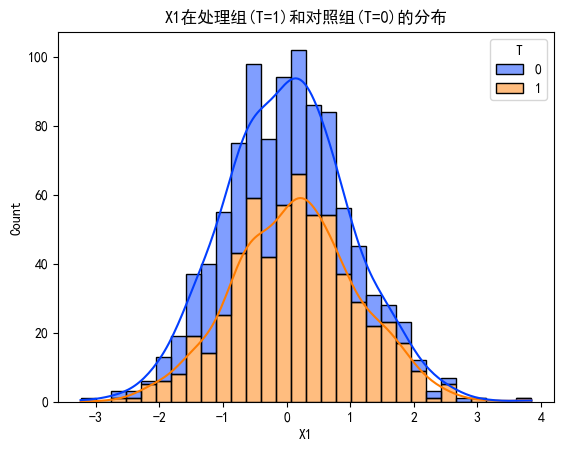

In [8]:
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
sns.histplot(data=data, x="X1", hue="T", bins=30, palette="bright", kde=True, multiple='stack')
plt.title('X1在处理组(T=1)和对照组(T=0)的分布')
plt.show()

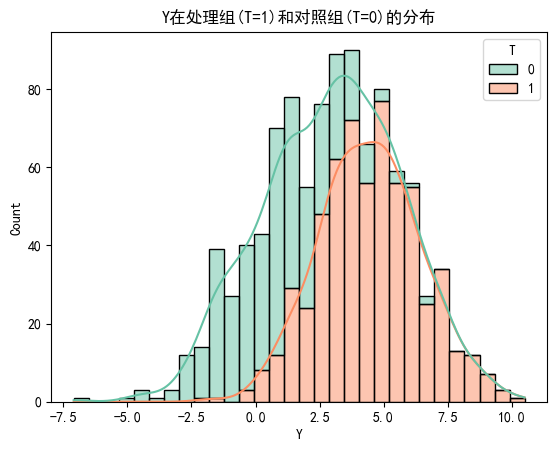

In [9]:
sns.histplot(data=data, x='Y', hue='T', bins=30, palette='Set2', kde=True, multiple='stack')
plt.title('Y在处理组(T=1)和对照组(T=0)的分布')
plt.show()

In [14]:
x_cov= data[['X1', 'X2', 'Z']]
y_treat = data['T']
prop_model = LogisticRegression()
prop_model.fit(x_cov, y_treat)
data['propensity_score'] = prop_model.predict_proba(x_cov)[:, 1]
data['propensity_score'].head()

0    0.522467
1    0.473219
2    0.541980
3    0.615295
4    0.690598
Name: propensity_score, dtype: float64

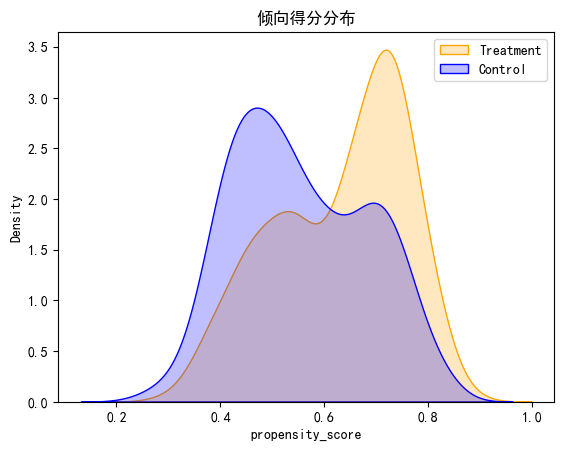

In [13]:
sns.kdeplot(data=data[data['T']==1], x='propensity_score', fill=True, color='orange', label='Treatment')
sns.kdeplot(data=data[data['T']==0], x='propensity_score', fill=True, color='blue', label='Control')
plt.title('倾向得分分布')
plt.legend()
plt.show()

In [15]:
data['weight'] = data['T']/data['propensity_score'] + (1-data['T'])/(1-data['propensity_score'])
ATE_ipw = np.sum(data['weight'] * data['T']*data['Y']/data['propensity_score'] - data['weight'] * (1-data['T'])*data['Y']/(1-data['propensity_score'])) / N
print(f'ATE: {ATE_ipw:.3f}')

ATE: 2.339


In [16]:
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(pd.concat([x_cov, data[['T']]], axis=1), data['Y'])
data['Y1_pred'] = reg_model.predict(pd.concat([x_cov, pd.DataFrame({'T':np.ones(N)})], axis=1))
data['Y0_pred'] = reg_model.predict(pd.concat([x_cov, pd.DataFrame({'T':np.zeros(N)})], axis=1))
CATE = data['Y1_pred'] - data['Y0_pred']
ATE_reg = CATE.mean()
print(f'回归调整法估计的ATE: {ATE_reg:.3f}')

回归调整法估计的ATE: 3.110


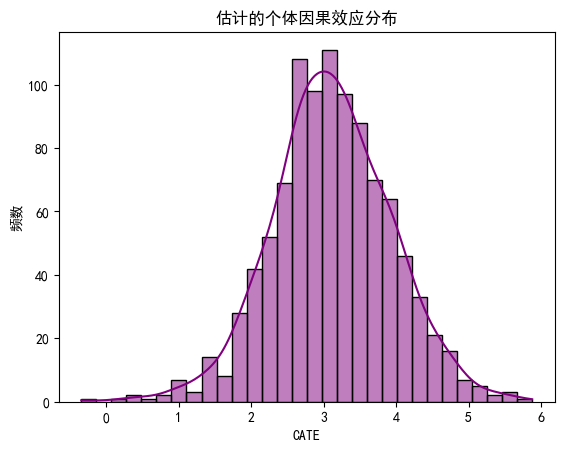

In [17]:
sns.histplot(CATE, bins=30, color='purple', kde=True)
plt.title('估计的个体因果效应分布')
plt.xlabel('CATE')
plt.ylabel('频数')
plt.show()

In [18]:
data['residual'] = data['Y'] - (data['T']*data['Y1_pred'] + (1-data['T'])*data['Y0_pred'])
DR_ATE = np.mean(data['Y1_pred'] - data['Y0_pred'] + data['T']*data['residual']/data['propensity_score'] - (1-data['T'])*data['residual']/(1-data['propensity_score']))
print(f'双重稳健法估计的ATE: {DR_ATE:.3f}')

双重稳健法估计的ATE: 3.087
